# Who disappears from the visible GPU market?
An empirical study of **listing visibility**, segmented by asking price, location,
reliability, verification and host. It develops the availability argument in
[The Compute Bazaar](https://www.adamsioud.com/exemplars/compute/feeling_the_compute.html#financialization).

**No field records completed rentals.** Disappearance can also mean query selection,
maintenance, delisting or downtime. The 64-offer cap and unspecified ordering prevent
identification of actual rental shares. We measure exits, returns and prolonged
absence candidates, rather than label them rentals.

Source: Marc Lammers, [Vast.ai RTX 3090 Spot Market dataset](https://huggingface.co/datasets/MarcusLammers/vast-rtx3090-market-6mo), CC BY 4.0.
The panel records listed offer prices per hour; GPU quantity and executed transaction
prices are absent. Geographic labels are provider-reported, not independently verified.

## What the segment comparison shows

The strongest distinction is **verification status**. Per 100 eligible visible observations, verified offers have 5.24 six-hour absence candidates, versus 0.90 for unverified offers. Within price bands, verified offers also have higher rates, including under the stricter requirement of three consecutive sightings before departure.

Under that stricter rule, **verified $0.10–$0.15/hour offers** have the highest rate among the displayed price-by-verification cells: **1.98 candidates per 100 eligible observations**, versus **0.28** for unverified offers at the same price. This is a descriptive visibility result, not a rental probability or causal verification effect.

The pooled price-only ranking is less robust: $0.15–$0.20/hour leads for the basic six-hour rule, while ≥$0.30/hour leads after requiring three prior consecutive appearances. Segment mix changes the answer.

**We cannot identify which segment was actually rented.** 88.1% of scans hit the listing cap; 47.4% of clean observed returns occur within roughly 30 minutes; 35.7% of machines visible in consecutive clean scans switch ask ID. These observations make both listing selection and offer identity important. A different ask ID may represent a different offer/configuration on the same machine, not necessarily a completed rental.


In [1]:
from pathlib import Path
import os, json, hashlib
import numpy as np
import pandas as pd
import pyarrow as pa
pa.set_cpu_count(2);pa.set_io_thread_count(2)
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT=Path.cwd()
if not (ROOT/'source-manifest.json').exists(): ROOT=ROOT/'modeling'/'vast-market'
DATA=ROOT/'data'; OUT=ROOT/'segments';OUT.mkdir(exist_ok=True)
plt.rcParams.update({'figure.figsize':(12,4),'figure.dpi':110,'axes.spines.top':False,
    'axes.spines.right':False,'axes.grid':True,'grid.alpha':.16,'font.size':10,
    'savefig.bbox':'tight','axes.prop_cycle':plt.cycler(color=['#a34b36','#326976','#a88949','#76628a','#59856a'])})

def save(name):
    plt.tight_layout();plt.savefig(OUT/f'{name}.png',dpi=150);plt.show()

s=pd.read_parquet(DATA/'snapshots.parquet')
m=pd.read_parquet(DATA/'snapshot_meta.parquet')
assert not s.duplicated(['snapshot_id','machine_id']).any()
assert not m.duplicated('snapshot_id').any()
print(f'{len(s):,} observations; {s.machine_id.nunique():,} machines; {s.host_id.nunique():,} hosts')
print('Period:',s.timestamp.min(),'to',s.timestamp.max())
identity=s.groupby('ask_id').agg(machines=('machine_id','nunique'),hosts=('host_id','nunique'))
assert identity.machines.eq(1).all() and identity.hosts.eq(1).all()
print('Identity check: every ask ID maps to one machine and one host.')
changes=s.groupby('machine_id').agg(countries=('geo_country','nunique'),verification_states=('verified','nunique'))
print('Machines observed with >1 country label:',int(changes.countries.gt(1).sum()))
print('Machines observed with both verification states:',int(changes.verification_states.gt(1).sum()))
print('Segments use contemporaneous attributes, not permanent machine classifications.')

1,624,024 observations; 1,662 machines; 614 hosts
Period: 2026-02-13 15:20:53.984000+00:00 to 2026-08-15 19:18:09.365000+00:00
Identity check: every ask ID maps to one machine and one host.
Machines observed with >1 country label: 88
Machines observed with both verification states: 690
Segments use contemporaneous attributes, not permanent machine classifications.


## 1. Define what we can observe
A clean adjacent pair has successful metadata at both ends, the same logger version,
5–15 minutes between timestamps, and no failed scan attempt between them. We exclude
missing metadata and broken scan sequences instead of interpreting these as disappearance.
A **visible exit** means a machine seen at the first scan is absent from the next clean scan.
It is not a transaction. Exposure counts are eligible machine-scan observations, not GPUs.

In [2]:
sc=s.groupby('snapshot_id').agg(timestamp=('timestamp','first'),offers=('machine_id','size'),
    median_price=('price_usd_hour','median'),p25=('price_usd_hour',lambda x:x.quantile(.25)),
    p75=('price_usd_hour',lambda x:x.quantile(.75))).sort_values('timestamp').reset_index()
sc=sc.merge(m[['snapshot_id','status','logger_version']],on='snapshot_id',how='left',validate='one_to_one')
sc['scan']=np.arange(len(sc))
ts=sc.timestamp.astype('int64').to_numpy() # pandas timestamp unit can vary; use matching units below.
# Use datetime64[ns] consistently for elapsed-time and failed-attempt search.
ts=sc.timestamp.to_numpy(dtype='datetime64[ns]').astype('int64')
failed=m.loc[m.status.ne('ok'),'timestamp'].to_numpy(dtype='datetime64[ns]').astype('int64')
failed.sort()
nfailed=np.searchsorted(failed,ts,side='right')
clean_in=sc.status.eq('ok')&sc.status.shift().eq('ok')&sc.logger_version.eq(sc.logger_version.shift())
clean_in &= sc.timestamp.diff().dt.total_seconds().between(300,900)
clean_in &= pd.Series(np.r_[0,np.diff(nfailed)],index=sc.index).eq(0)
sc['clean_in']=clean_in
sc['clean_next']=sc.clean_in.shift(-1,fill_value=False)
sc['block']=(~sc.clean_in).cumsum()
sc['both_capped']=sc.offers.eq(64)&sc.offers.shift(-1).eq(64)
sc['both_uncapped']=sc.offers.lt(64)&sc.offers.shift(-1).lt(64)
s=s.merge(sc[['snapshot_id','scan','block','clean_next','both_capped','both_uncapped']],on='snapshot_id',validate='many_to_one')
s=s.sort_values(['machine_id','scan']).reset_index(drop=True)
g=s.groupby('machine_id',sort=False)
s['next_scan']=g.scan.shift(-1)
s['next_seen']=g.timestamp.shift(-1)
s['next_block']=g.block.shift(-1)
s['next_ask']=g.ask_id.shift(-1)
s['exit']=s.clean_next&s.next_scan.ne(s.scan+1)
s['same_ask_return']=s.ask_id.eq(s.next_ask)
s['absence_hours']=(s.next_seen-s.timestamp).dt.total_seconds()/3600
s['observed_clean_return']=s.exit&s.next_block.eq(s.block)&s.next_seen.notna()
s['day']=s.timestamp.dt.floor('D')
s['month']=s.timestamp.dt.year*100+s.timestamp.dt.month
s['price_rank']=s.groupby('snapshot_id').price_usd_hour.rank(pct=True,method='average')
PRICE=['<$0.10','$0.10–0.15','$0.15–0.20','$0.20–0.30','≥$0.30']
s['price_band']=pd.cut(s.price_usd_hour,[-np.inf,.10,.15,.20,.30,np.inf],labels=PRICE,right=False)
s['relative_price']=pd.cut(s.price_rank,[0,.25,.5,.75,1],labels=['Lowest quarter','Second quarter','Third quarter','Highest quarter'],include_lowest=True)
s['reliability_band']=pd.cut(s.reliability,[-np.inf,.98,.995,np.inf],labels=['<98%','98–99.5%','≥99.5%'],right=False)
s['verification']=s.verified.map({True:'Verified',False:'Unverified'}).fillna('Unknown')
top_countries=s.geo_country.value_counts().head(8).index
s['country_group']=s.geo_country.where(s.geo_country.isin(top_countries),'Other')
# Require a full six hours of clean observation opportunity for prolonged absence.
block_end=sc.groupby('block').timestamp.max()
s['followup_hours']=(s.block.map(block_end)-s.timestamp).dt.total_seconds()/3600
s['eligible6']=s.clean_next&s.followup_hours.ge(6)
# Absence is checked at all observed scans through six hours, including any lack of return.
s['absent6']=s.eligible6&s.exit&(s.absence_hours.gt(6)|s.next_seen.isna())
# Repeat at one and 24 hours for sensitivity, accounting for right censoring.
for h in [1,24]:
    s[f'eligible{h}']=s.clean_next&s.followup_hours.ge(h)
    s[f'absent{h}']=s[f'eligible{h}']&s.exit&(s.absence_hours.gt(h)|s.next_seen.isna())
print('Observed scans:',len(sc),'| 64-offer scans:',f'{sc.offers.eq(64).mean():.1%}')
print('Clean adjacent pairs:',int(sc.clean_next.sum()),'| failed scan attempts:',len(failed))
print('Unknown-metadata observed scans:',int(sc.status.isna().sum()))
print('Clean observation blocks:',sc.block.nunique())

Observed scans: 26066 | 64-offer scans: 88.1%
Clean adjacent pairs: 25941 | failed scan attempts: 7
Unknown-metadata observed scans: 118
Clean observation blocks: 125


,observations,median_price,machines,hosts
month,,,,
202602,121984,0.1222,459,193
202603,285580,0.1348,642,265
202604,276396,0.1356,723,290
202605,242439,0.1744,841,369
202606,275737,0.1754,867,370
202607,285760,0.1489,829,362
202608,136128,0.1483,697,318


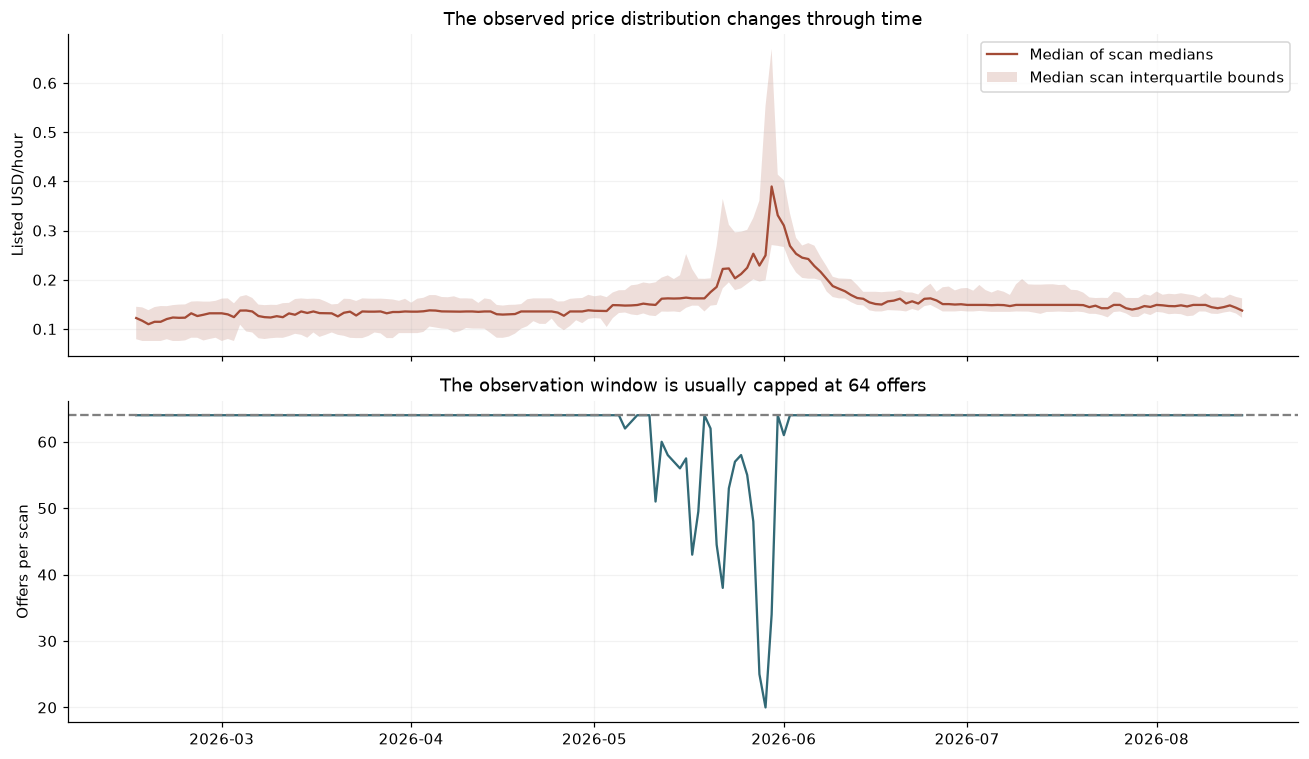

In [3]:
# Recompute monthly prices and scan composition without overclaiming market-wide coverage.
monthly=s.groupby('month').agg(observations=('machine_id','size'),median_price=('price_usd_hour','median'),machines=('machine_id','nunique'),hosts=('host_id','nunique'))
monthly.to_csv(OUT/'monthly.csv')
display(monthly)
daily=sc.set_index('timestamp')[['median_price','p25','p75','offers']].resample('D').median()
fig,axes=plt.subplots(2,1,figsize=(12,7),sharex=True)
axes[0].plot(daily.index,daily.median_price,label='Median of scan medians')
axes[0].fill_between(daily.index,daily.p25,daily.p75,alpha=.18,label='Median scan interquartile bounds')
axes[0].set(ylabel='Listed USD/hour',title='The observed price distribution changes through time');axes[0].legend()
axes[1].plot(daily.index,daily.offers,color='#326976');axes[1].axhline(64,color='grey',ls='--')
axes[1].set(ylabel='Offers per scan',title='The observation window is usually capped at 64 offers')
save('01_price_and_cap')

## 2. Which segments disappear more often?
All rates below use exposure denominators: exits per 100 eligible visible observations.
This prevents a large segment being called more rental-active just because it has more rows.
A six-hour absence candidate requires continued successful scans for the next six hours,
and no observed return by then. There is no claim that the machine was rented during it.
Segments are assigned using the last observed attributes before the exit.

**Price Band**

,exposures,exits,machines,hosts,exit_pct,exposures6,absences6,absence6_pct,exit_share_pct,exposure_share_pct,machine_balanced_exit_pct
price_band,,,,,,,,,,,
<$0.10,240170,62750,353,185,26.127,238920,1855,0.776,10.212,14.862,33.238
$0.10–0.15,649779,254401,1033,446,39.152,645077,16347,2.534,41.402,40.208,48.880
$0.15–0.20,394244,178504,927,391,45.278,392158,13939,3.554,29.050,24.396,51.695
$0.20–0.30,274112,101669,804,335,37.09,273162,9134,3.344,16.546,16.962,47.627
≥$0.30,57719,17140,384,190,29.696,57683,1609,2.789,2.789,3.572,37.538


**Relative Price**

,exposures,exits,machines,hosts,exit_pct,exposures6,absences6,absence6_pct,exit_share_pct,exposure_share_pct,machine_balanced_exit_pct
relative_price,,,,,,,,,,,
Lowest quarter,399457,118571,1019,427,29.683,397193,6198,1.56,19.297,24.719,39.531
Second quarter,405023,150886,1219,488,37.254,402802,9461,2.349,24.556,25.063,43.766
Third quarter,403012,175916,1207,484,43.65,400748,14004,3.494,28.629,24.938,48.901
Highest quarter,408532,169091,958,402,41.39,406257,13221,3.254,27.518,25.28,52.902


**Reliability Band**

,exposures,exits,machines,hosts,exit_pct,exposures6,absences6,absence6_pct,exit_share_pct,exposure_share_pct,machine_balanced_exit_pct
reliability_band,,,,,,,,,,,
<98%,299616,105640,1316,551,35.258,298003,7090,2.379,17.192,18.54,39.898
98–99.5%,657419,242070,1093,453,36.821,653863,15094,2.308,39.395,40.681,48.754
≥99.5%,658989,266754,775,307,40.479,655134,20700,3.16,43.412,40.778,53.225


**Verification**

,exposures,exits,machines,hosts,exit_pct,exposures6,absences6,absence6_pct,exit_share_pct,exposure_share_pct,machine_balanced_exit_pct
verification,,,,,,,,,,,
Unverified,957053,239312,1379,583,25.005,951787,8526,0.896,38.946,59.223,32.253
Verified,658971,375152,971,343,56.93,655213,34358,5.244,61.054,40.777,66.536


**Country Group**

,exposures,exits,machines,hosts,exit_pct,exposures6,absences6,absence6_pct,exit_share_pct,exposure_share_pct,machine_balanced_exit_pct
country_group,,,,,,,,,,,
BG,47382,20442,21,7,43.143,47041,744,1.582,3.327,2.932,51.073
CA,308518,98206,245,75,31.832,306835,6860,2.236,15.982,19.091,47.450
CN,134415,49945,99,27,37.157,134174,2082,1.552,8.128,8.318,46.891
CZ,136849,46400,49,7,33.906,136037,3785,2.782,7.551,8.468,51.681
ES,95959,38395,56,23,40.012,95502,2008,2.103,6.249,5.938,49.537
FR,37044,10596,52,30,28.604,36858,920,2.496,1.724,2.292,42.728
Other,490676,191840,742,297,39.097,487649,15636,3.206,31.221,30.363,47.260
PL,83787,39303,57,16,46.908,83304,2366,2.84,6.396,5.185,51.636
US,281394,119337,413,171,42.409,279600,8483,3.034,19.421,17.413,49.871


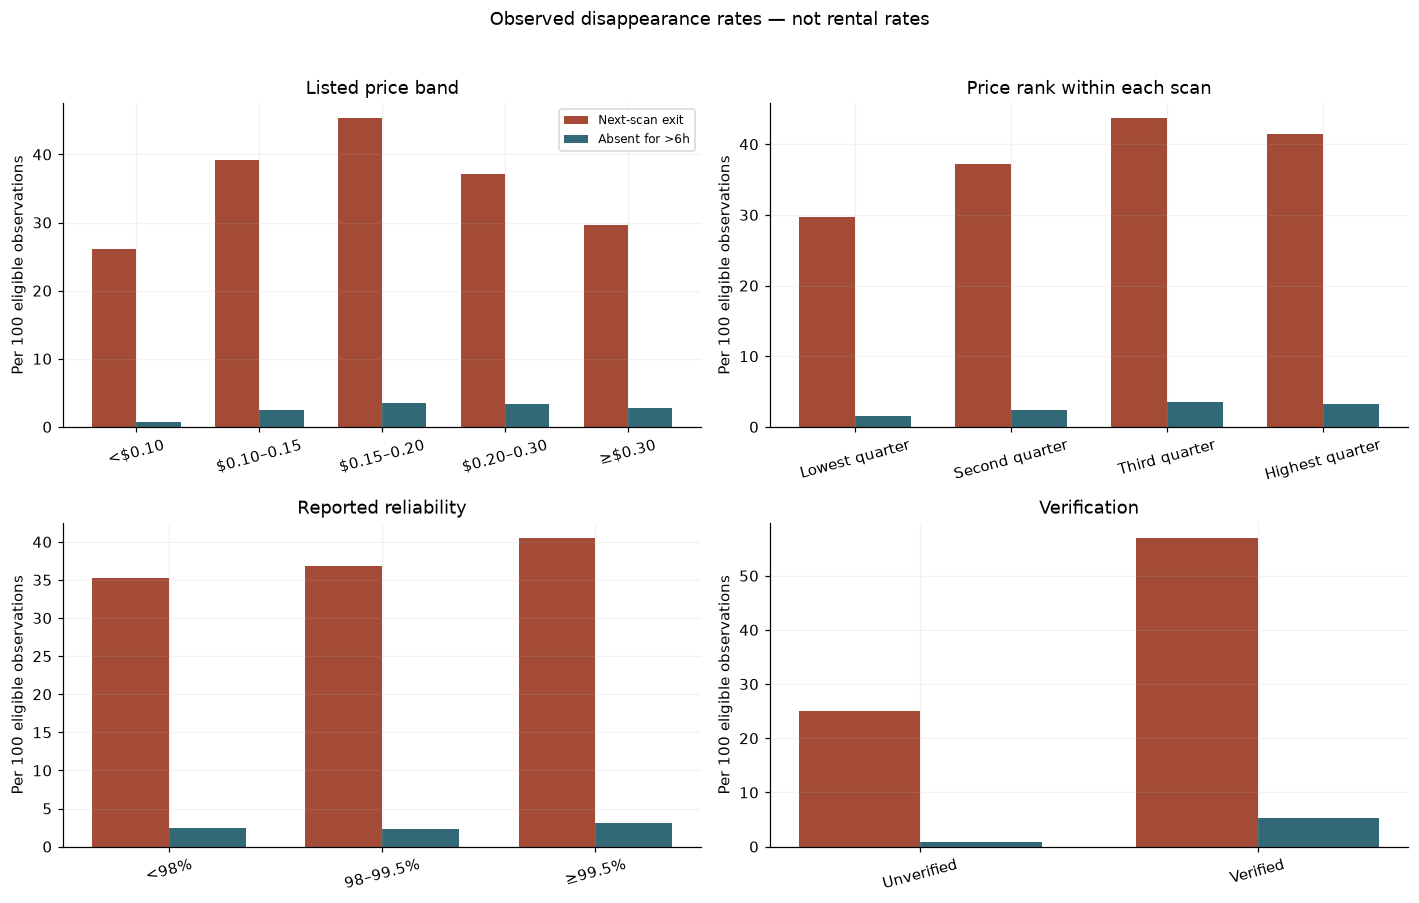

In [4]:
def segment_table(col):
    q=s[s.clean_next].groupby(col,observed=True).agg(exposures=('machine_id','size'),exits=('exit','sum'),machines=('machine_id','nunique'),hosts=('host_id','nunique'))
    q['exit_pct']=100*q.exits/q.exposures
    z=s[s.eligible6].groupby(col,observed=True).agg(exposures6=('machine_id','size'),absences6=('absent6','sum'))
    q=q.join(z);q['absence6_pct']=100*q.absences6/q.exposures6
    q['exit_share_pct']=100*q.exits/q.exits.sum()
    q['exposure_share_pct']=100*q.exposures/q.exposures.sum()
    # Mean per-machine exit rate is a different estimand; show it as a sensitivity check.
    mr=s[s.clean_next].groupby([col,'machine_id'],observed=True).exit.agg(['mean','size'])
    q['machine_balanced_exit_pct']=100*mr[mr['size']>=100].groupby(level=0)['mean'].mean()
    q.to_csv(OUT/f'segment_{col}.csv')
    return q

tables={c:segment_table(c) for c in ['price_band','relative_price','reliability_band','verification','country_group']}
for c,t in tables.items():
    display(Markdown('**'+c.replace('_',' ').title()+'**'));display(t.round(3))
fig,axes=plt.subplots(2,2,figsize=(13,8))
for ax,col,title in zip(axes.flat,['price_band','relative_price','reliability_band','verification'],['Listed price band','Price rank within each scan','Reported reliability','Verification']):
    t=tables[col];pos=np.arange(len(t))
    ax.bar(pos-.18,t.exit_pct,width=.36,label='Next-scan exit',color='#a34b36')
    ax.bar(pos+.18,t.absence6_pct,width=.36,label='Absent for >6h',color='#326976')
    ax.set(xticks=pos,xticklabels=t.index.astype(str),ylabel='Per 100 eligible observations',title=title)
    ax.tick_params(axis='x',labelrotation=15)
axes[0,0].legend(fontsize=8)
fig.suptitle('Observed disappearance rates — not rental rates',y=1.02)
save('02_segment_rates')

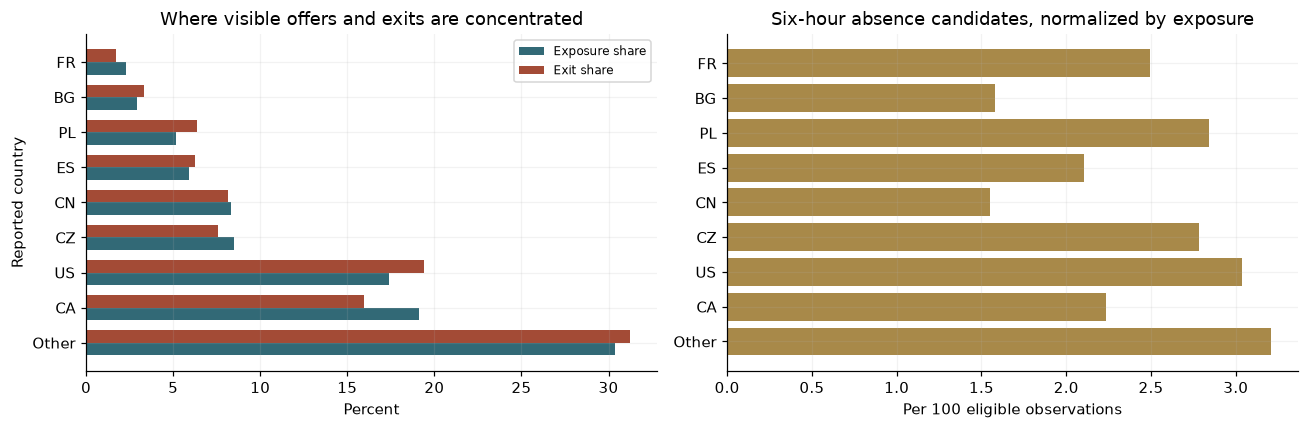

In [5]:
# Exposure composition and exits side by side; do not confuse count shares with hazards.
t=tables['country_group'].sort_values('exposures',ascending=False)
fig,axes=plt.subplots(1,2,figsize=(12,4))
y=np.arange(len(t))
axes[0].barh(y-.18,t.exposure_share_pct,height=.36,label='Exposure share',color='#326976')
axes[0].barh(y+.18,t.exit_share_pct,height=.36,label='Exit share',color='#a34b36')
axes[0].set(yticks=y,yticklabels=t.index,ylabel='Reported country',xlabel='Percent',title='Where visible offers and exits are concentrated');axes[0].legend(fontsize=8)
axes[1].barh(y,t.absence6_pct,color='#a88949');axes[1].set(yticks=y,yticklabels=t.index,xlabel='Per 100 eligible observations',title='Six-hour absence candidates, normalized by exposure')
save('03_geography')

## 3. Does the result persist over time and under stricter definitions?
Changes in segment composition can generate a pooled result. We therefore inspect
month-by-month hazards, machine-balanced rates, and one-/six-/24-hour thresholds.
These are descriptive comparisons, not causal price effects or independent statistical tests.

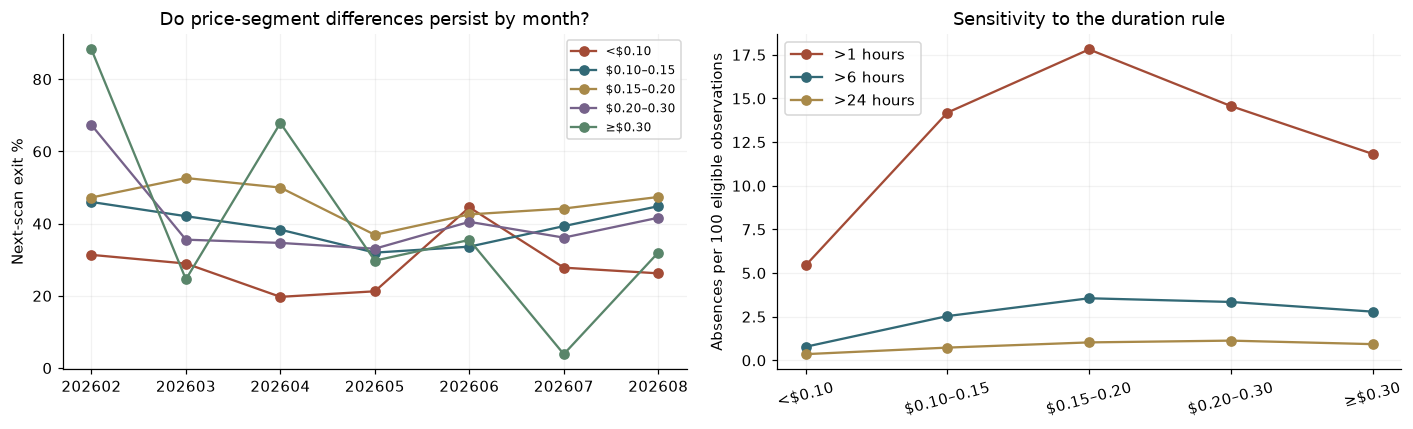

In [6]:
month_band=s[s.clean_next].groupby(['month','price_band'],observed=True).exit.agg(['mean','size'])
month_band.to_csv(OUT/'monthly_price_exit_rates.csv')
fig,axes=plt.subplots(1,2,figsize=(13,4))
for band in PRICE:
    q=month_band.xs(band,level='price_band');axes[0].plot(q.index.astype(str),q['mean']*100,marker='o',label=band)
axes[0].set(ylabel='Next-scan exit %',title='Do price-segment differences persist by month?');axes[0].legend(fontsize=8)
sens=[]
for h in [1,6,24]:
    q=s[s[f'eligible{h}']].groupby('price_band',observed=True).agg(n=('machine_id','size'),events=(f'absent{h}','sum'))
    q['rate']=100*q.events/q.n;q['hours']=h;sens.append(q.reset_index())
    axes[1].plot(q.index.astype(str),q.rate,marker='o',label=f'>{h} hours')
axes[1].set(ylabel='Absences per 100 eligible observations',title='Sensitivity to the duration rule');axes[1].legend();axes[1].tick_params(axis='x',labelrotation=15)
save('04_time_and_duration')
sens=pd.concat(sens,ignore_index=True);sens.to_csv(OUT/'duration_sensitivity.csv',index=False)

## 4. Returns: rapid reappearance versus longer spells out of view
Duration is last sighting to first return, not exact rental duration. Events are only
timed when the whole gap lies within one uninterrupted clean observation block.
Unknown outcomes are retained separately. This observed-return subset is selected:
it excludes never-returning machines and gaps crossing collection breaks.

,events,same_ask_fraction
duration_band,,
≈30 min or less,289707,0.658165
30–60 min,102397,0.656093
1–6 h,178664,0.65734
6–24 h,29556,0.661456
1–3 days,7150,0.647692
>3 days,4075,0.570061


Visible exits: 614464 | observed clean returns: 611549 | unresolved or cross-break: 2915


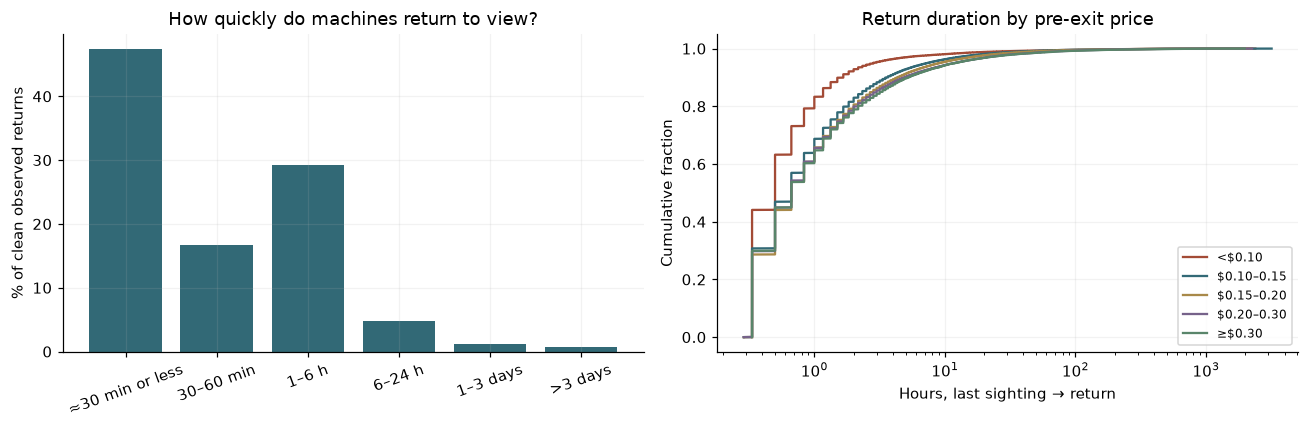

In [7]:
ex=s[s.exit].copy()
returned=ex[ex.observed_clean_return].copy()
returned['duration_band']=pd.cut(returned.absence_hours,[0,.51,1,6,24,72,np.inf],labels=['≈30 min or less','30–60 min','1–6 h','6–24 h','1–3 days','>3 days'])
rates=returned.groupby('duration_band',observed=True).agg(events=('machine_id','size'),same_ask_fraction=('same_ask_return','mean'))
rates.to_csv(OUT/'return_durations.csv')
display(rates)
print('Visible exits:',len(ex),'| observed clean returns:',len(returned),'| unresolved or cross-break:',len(ex)-len(returned))
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].bar(rates.index.astype(str),100*rates.events/rates.events.sum(),color='#326976');axes[0].set(ylabel='% of clean observed returns',title='How quickly do machines return to view?');axes[0].tick_params(axis='x',labelrotation=20)
for band in PRICE:
    x=np.sort(returned.loc[returned.price_band==band,'absence_hours'].to_numpy())
    if len(x):axes[1].plot(x,np.arange(1,len(x)+1)/len(x),label=band)
axes[1].set(xscale='log',xlabel='Hours, last sighting → return',ylabel='Cumulative fraction',title='Return duration by pre-exit price');axes[1].legend(fontsize=8)
save('05_returns')

## 5. Observation bias and host concentration
Compare transitions with both scans capped and both scans below cap. Uncapped scans
still do not certify exhaustive inventory: query filters and selection remain unknown.
Host concentration matters because one large supplier can dominate a segment's signal.

,collection_state,exposures,exit_pct,machines
0,Both scans capped,1446720,38.907,1615
1,Both below cap,140396,29.918,938
2,Mixed,28908,33.136,920


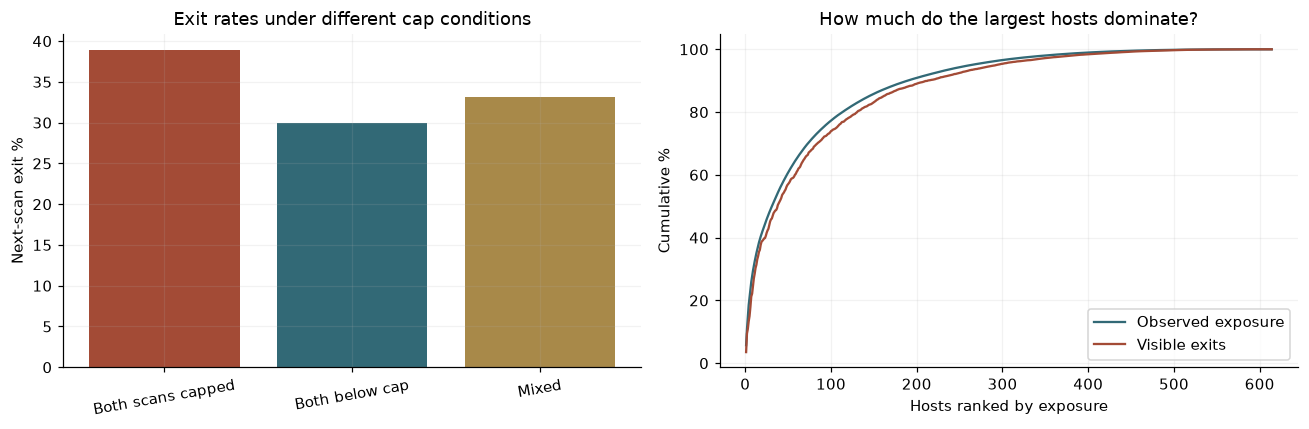

,mean,size,all_hosts_exit_pct,without_top5_exit_pct
price_band,,,,
<$0.10,0.294,179307,26.127,29.429
$0.10–0.15,0.404,516503,39.152,40.412
$0.15–0.20,0.476,344042,45.278,47.552
$0.20–0.30,0.436,188405,37.09,43.626
≥$0.30,0.314,47852,29.696,31.443


In [8]:
cap=[]
for name,mask in [('Both scans capped',s.both_capped),('Both below cap',s.both_uncapped),('Mixed',~s.both_capped&~s.both_uncapped)]:
    q=s[s.clean_next&mask]
    cap.append({'collection_state':name,'exposures':len(q),'exit_pct':100*q.exit.mean(),'machines':q.machine_id.nunique()})
cap=pd.DataFrame(cap);cap.to_csv(OUT/'cap_sensitivity.csv',index=False);display(cap.round(3))
host=s[s.clean_next].groupby('host_id').agg(exposures=('machine_id','size'),exits=('exit','sum'),machines=('machine_id','nunique'))
host['exit_pct']=100*host.exits/host.exposures
host=host.sort_values('exposures',ascending=False)
host.to_csv(OUT/'hosts.csv')
# Compare price-band hazards after removing the five largest hosts by exposure.
large_hosts=host.head(5).index
host_sens=s[s.clean_next&~s.host_id.isin(large_hosts)].groupby('price_band',observed=True).exit.agg(['mean','size'])
host_sens['all_hosts_exit_pct']=tables['price_band'].exit_pct
host_sens['without_top5_exit_pct']=100*host_sens['mean']
host_sens.to_csv(OUT/'host_sensitivity.csv')
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].bar(cap.collection_state,cap.exit_pct,color=['#a34b36','#326976','#a88949']);axes[0].set(ylabel='Next-scan exit %',title='Exit rates under different cap conditions');axes[0].tick_params(axis='x',labelrotation=10)
axes[1].plot(np.arange(1,len(host)+1),100*host.exposures.cumsum()/host.exposures.sum(),label='Observed exposure',color='#326976')
axes[1].plot(np.arange(1,len(host)+1),100*host.exits.cumsum()/host.exits.sum(),label='Visible exits',color='#a34b36')
axes[1].set(xlabel='Hosts ranked by exposure',ylabel='Cumulative %',title='How much do the largest hosts dominate?');axes[1].legend()
save('06_observation_bias')
display(host_sens.round(3))

## 6. A week of machine visibility
Select the 20 machines most frequently observed in the middle complete week, regardless
of exit score. A blank cell means absent from a successful query, not rented. Grey columns
mark collection breaks/unknown metadata. This view makes repeated appearances visible.

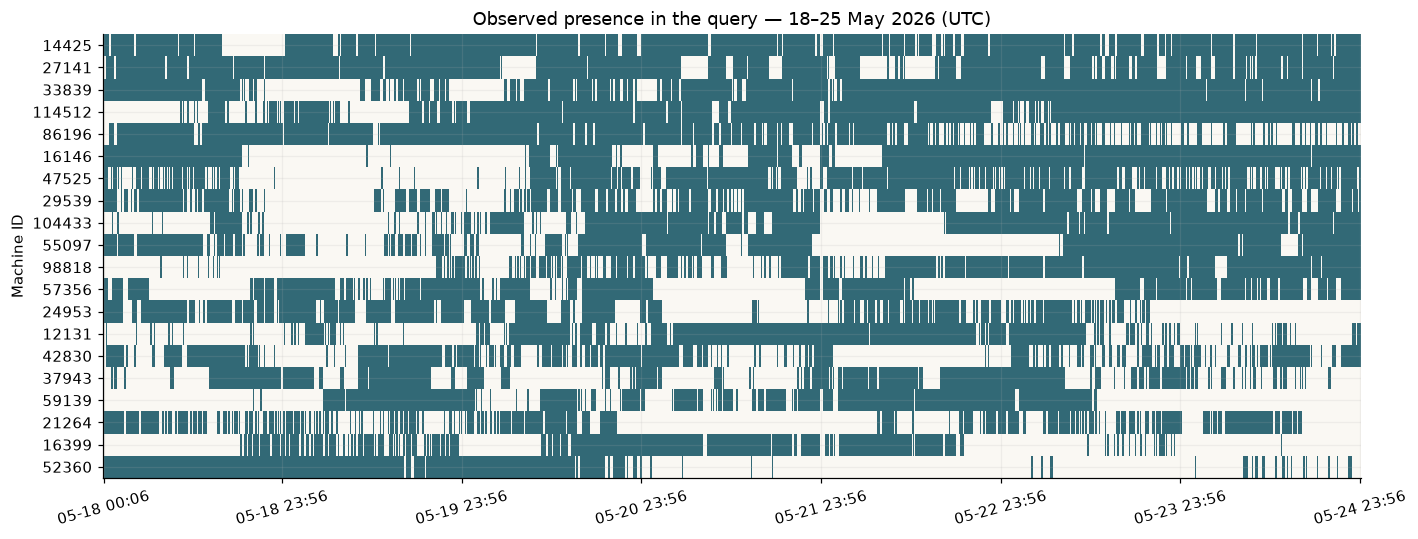

In [9]:
a=pd.Timestamp('2026-05-18',tz='UTC');b=a+pd.Timedelta('7D')
w=s[(s.timestamp>=a)&(s.timestamp<b)]
ids=w.machine_id.value_counts().head(20).index
week_sc=sc[(sc.timestamp>=a)&(sc.timestamp<b)]
vis=w[w.machine_id.isin(ids)].assign(visible=1).pivot(index='machine_id',columns='scan',values='visible').reindex(index=ids,columns=week_sc.scan).fillna(0)
fig,ax=plt.subplots(figsize=(13,5))
ax.imshow(vis,aspect='auto',cmap=matplotlib.colors.ListedColormap(['#faf8f3','#326976']),vmin=0,vmax=1,interpolation='nearest')
for j,bad in enumerate(~week_sc.clean_in.to_numpy()):
    if bad:ax.axvspan(j-.5,j+.5,color='grey',alpha=.5,lw=0)
ticks=np.linspace(0,len(week_sc)-1,8).astype(int)
ax.set(yticks=np.arange(len(ids)),yticklabels=ids,xticks=ticks,xticklabels=week_sc.iloc[ticks].timestamp.dt.strftime('%m-%d %H:%M'),ylabel='Machine ID',title='Observed presence in the query — 18–25 May 2026 (UTC)')
ax.tick_params(axis='x',labelrotation=15);save('07_visibility_raster')

## 7. Concrete prolonged-absence examples
To inspect candidates rather than declare rentals, select departures that follow at
least three consecutive clean appearances and later return after 6–72 hours in the
same observation block. Show a spread of price segments. This is a stricter visibility
pattern, still compatible with query selection, maintenance or other non-rental causes.

In [10]:
prev_scan=s.groupby('machine_id').scan.shift()
new_spell=prev_scan.ne(s.scan-1)|s.block.ne(s.groupby('machine_id').block.shift())
s['spell']=new_spell.groupby(s.machine_id).cumsum()
s['consecutive_seen']=s.groupby(['machine_id','spell']).cumcount()+1
c=s[s.observed_clean_return&s.absence_hours.between(6,72)&s.consecutive_seen.ge(3)].copy()
examples=c.sort_values('consecutive_seen',ascending=False).groupby('price_band',observed=True).head(2)
cols=['machine_id','host_id','timestamp','next_seen','absence_hours','consecutive_seen','price_usd_hour','price_band','geo_country','reliability','verified','ask_id','next_ask','same_ask_return']
examples[cols].to_csv(OUT/'prolonged_examples.csv',index=False)
display(examples[cols].sort_values('price_usd_hour'))
strict=s[s.eligible6&s.consecutive_seen.ge(3)].groupby('price_band',observed=True).agg(exposures=('machine_id','size'),absences=('absent6','sum'))
strict['rate_pct']=100*strict.absences/strict.exposures;strict.to_csv(OUT/'stable_spell_sensitivity.csv');display(strict.round(4))

,machine_id,host_id,timestamp,next_seen,absence_hours,consecutive_seen,price_usd_hour,price_band,geo_country,reliability,verified,ask_id,next_ask,same_ask_return
206606,15501,85323,2026-04-19 12:16:30.467000+00:00,2026-04-19 23:46:30.500000+00:00,11.500009,221,0.0756,<$0.10,CA,0.9943,False,21206407,21206409,False
483666,27141,143846,2026-03-31 06:46:29.181000+00:00,2026-03-31 20:16:29.219000+00:00,13.500011,352,0.0815,<$0.10,DE,0.9885,False,30408930,30408932,False
173176,14425,85323,2026-06-21 11:06:34.554000+00:00,2026-06-21 17:56:34.577000+00:00,6.833340,1197,0.1356,$0.10–0.15,CA,0.9565,False,32353633,32353633,True
1383256,98818,155385,2026-06-22 01:06:34.598000+00:00,2026-06-22 12:16:34.630000+00:00,11.166676,829,0.1489,$0.10–0.15,CN,0.9899,False,36159295,36159295,True
343020,20409,50627,2026-04-02 17:26:29.345000+00:00,2026-04-02 23:56:29.367000+00:00,6.500006,302,0.1507,$0.15–0.20,CA,0.9981,False,17580329,17580329,True
342718,20409,50627,2026-03-31 07:16:29.183000+00:00,2026-03-31 15:16:29.202000+00:00,8.000005,275,0.1507,$0.15–0.20,CA,0.9981,False,17580329,17580329,True
381833,22784,124327,2026-07-21 14:16:36.592000+00:00,2026-07-23 14:13:53.620000+00:00,47.954730,131,0.2022,$0.20–0.30,US,0.9933,True,45102772,45102772,True
132615,13728,1647,2026-06-07 14:26:33.636000+00:00,2026-06-08 18:56:33.723000+00:00,28.500024,122,0.2523,$0.20–0.30,IS,0.9982,True,8993415,8993415,True
586913,34330,3497,2026-05-21 16:16:32.543000+00:00,2026-05-22 00:16:32.566000+00:00,8.000006,67,0.3015,≥$0.30,CZ,0.9929,True,20375219,20375218,False
223190,16146,85323,2026-05-28 09:16:32.969000+00:00,2026-05-29 06:56:33.024000+00:00,21.666682,151,0.7356,≥$0.30,CA,0.9931,False,36564736,36564738,False


,exposures,absences,rate_pct
price_band,,,
<$0.10,146683,612,0.4172
$0.10–0.15,306543,1448,0.4724
$0.15–0.20,155795,1217,0.7812
$0.20–0.30,134893,993,0.7361
≥$0.30,33302,279,0.8378


## 8. Price and verification together
Verification and price are correlated attributes. These cross-segment rates reveal
whether a pooled result is merely mixing different visible products. The stricter
panel only includes observations preceded by at least three consecutive appearances.
Neither panel identifies rental probability. Numbers in parentheses are eligible exposures.

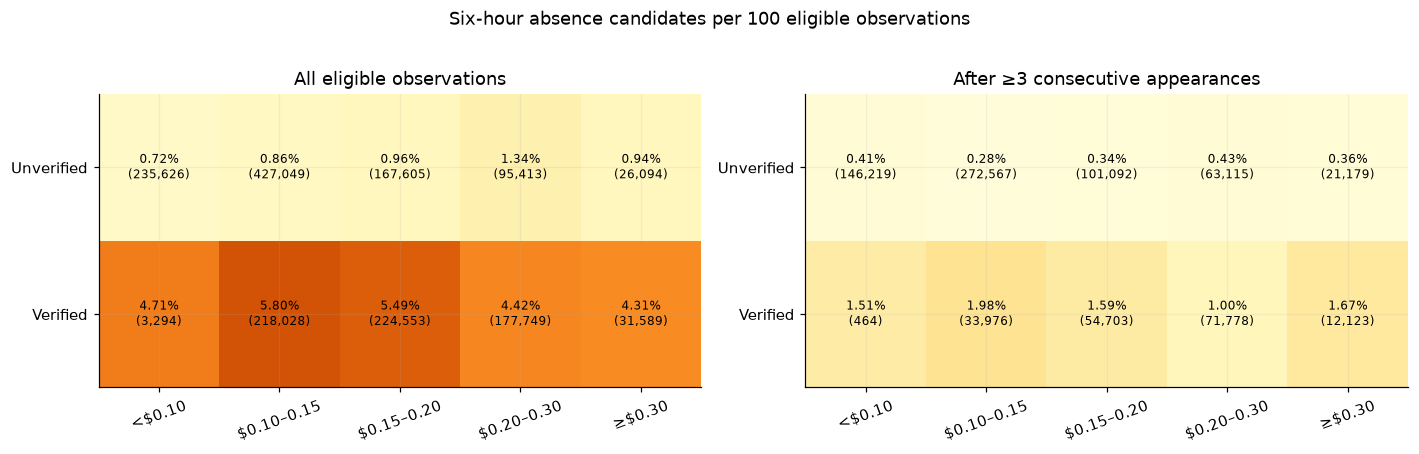

Among machines visible in consecutive clean scans, 35.68% switch ask ID.
This is why exits are defined using machine_id, not ask_id.


In [11]:
cross_tables=[]
fig,axes=plt.subplots(1,2,figsize=(13,4))
for ax,stable,title in zip(axes,[False,True],['All eligible observations','After ≥3 consecutive appearances']):
    q=s[s.eligible6 & (s.consecutive_seen.ge(3) if stable else True)]
    t=q.groupby(['verification','price_band'],observed=True).agg(n=('machine_id','size'),events=('absent6','sum'))
    t['rate']=100*t.events/t.n;t['stable_only']=stable;cross_tables.append(t.reset_index())
    mat=t.rate.unstack('price_band').reindex(index=['Unverified','Verified'],columns=PRICE)
    sizes=t.n.unstack('price_band').reindex(index=mat.index,columns=PRICE)
    im=ax.imshow(mat.to_numpy(dtype=float),cmap='YlOrBr',vmin=0,vmax=8,aspect='auto')
    for i in range(2):
        for j in range(5):
            ax.text(j,i,f'{mat.iloc[i,j]:.2f}%\n({int(sizes.iloc[i,j]):,})',ha='center',va='center',fontsize=8,color='black')
    ax.set(xticks=np.arange(5),xticklabels=PRICE,yticks=[0,1],yticklabels=mat.index,title=title)
    ax.tick_params(axis='x',labelrotation=20)
fig.suptitle('Six-hour absence candidates per 100 eligible observations',y=1.02)
save('08_price_verification')
pd.concat(cross_tables).to_csv(OUT/'price_verification.csv',index=False)
continuous=s.clean_next&s.next_scan.eq(s.scan+1)
id_churn=100*(~s.loc[continuous,'same_ask_return']).mean()
print(f'Among machines visible in consecutive clean scans, {id_churn:.2f}% switch ask ID.')
print('This is why exits are defined using machine_id, not ask_id.')

## 9. Individual absence-and-return patterns
One example per price band, ranked by the number of consecutive appearances before
departure. The shaded gap is unobserved machine visibility, not a known rental period.
Dots show listed prices when that machine is present; nothing is interpolated across gaps.

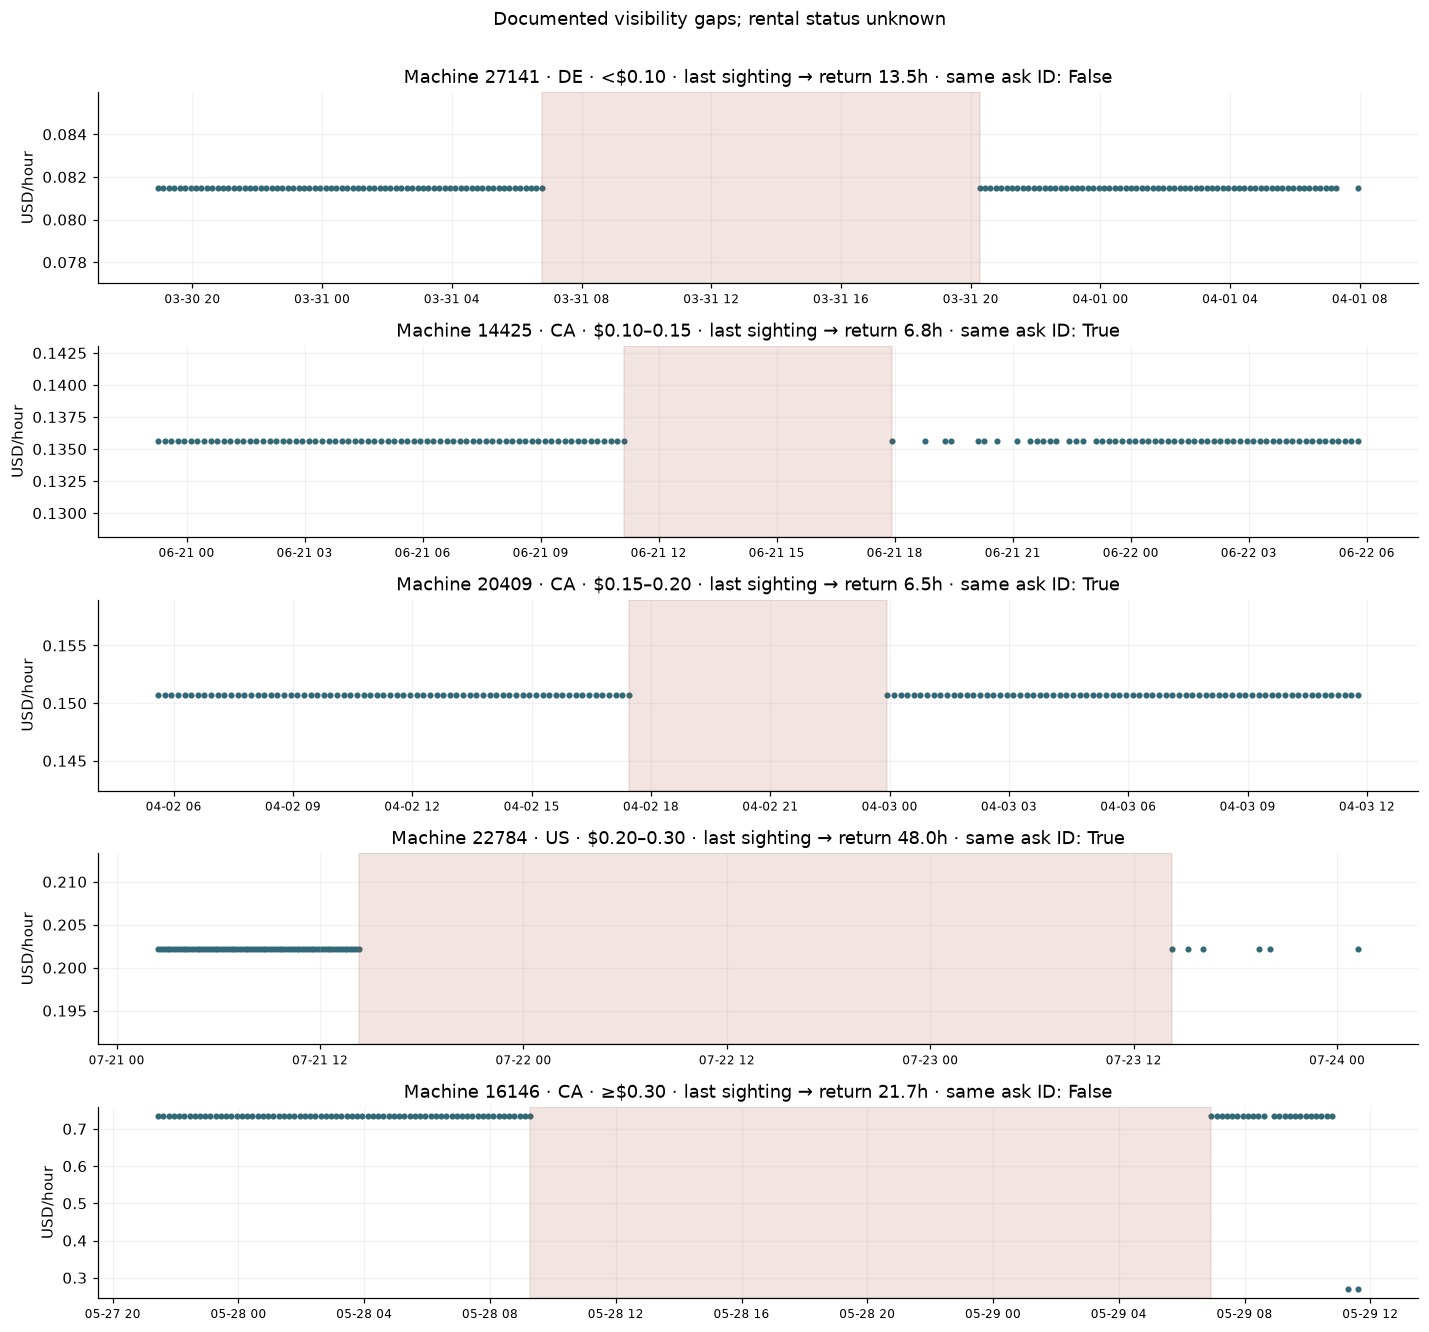

In [12]:
chosen=c.sort_values('consecutive_seen',ascending=False).groupby('price_band',observed=True).head(1).sort_values('price_usd_hour')
fig,axes=plt.subplots(len(chosen),1,figsize=(13,2.4*len(chosen)),squeeze=False)
for ax,(_,ev) in zip(axes.flat,chosen.iterrows()):
    q=s[(s.machine_id==ev.machine_id)&(s.timestamp>=ev.timestamp-pd.Timedelta('12h'))&(s.timestamp<=ev.next_seen+pd.Timedelta('12h'))]
    ax.scatter(q.timestamp,q.price_usd_hour,s=9,color='#326976')
    ax.axvspan(ev.timestamp,ev.next_seen,color='#a34b36',alpha=.15)
    ax.set(ylabel='USD/hour',title=f'Machine {ev.machine_id} · {ev.geo_country} · {ev.price_band} · last sighting → return {ev.absence_hours:.1f}h · same ask ID: {ev.same_ask_return}')
    ax.tick_params(axis='x',labelsize=8)
fig.suptitle('Documented visibility gaps; rental status unknown',y=1.005)
save('09_individual_gaps')

In [13]:
assert (s.absent6 <= s.exit).all()
assert s.loc[s.absent6,'followup_hours'].ge(6).all()
summary={'rows':len(s),'machines':s.machine_id.nunique(),'hosts':s.host_id.nunique(),
 'scans':len(sc),'capped_fraction':float(sc.offers.eq(64).mean()),'clean_pairs':int(sc.clean_next.sum()),
 'exposures':int(s.clean_next.sum()),'exits':int(s.exit.sum()),'exit_pct':float(100*s.loc[s.clean_next,'exit'].mean()),
 'continuous_machine_ask_id_change_pct':float(id_churn),'clean_returns':len(returned),'returns_within_30m_pct':float(100*returned.absence_hours.le(.51).mean()),
 'same_ask_return_pct':float(100*returned.same_ask_return.mean()),
 'six_hour_candidates':int(s.absent6.sum()),'six_hour_exposures':int(s.eligible6.sum()),
 'top5_host_exposure_pct':float(100*host.head(5).exposures.sum()/host.exposures.sum()),
 'top5_host_exit_pct':float(100*host.head(5).exits.sum()/host.exits.sum()),
 'strict_6to72h_return_candidates':len(c),
 'highest_exit_price_band':str(tables['price_band'].exit_pct.idxmax()),
 'highest_6h_price_band':str(tables['price_band'].absence6_pct.idxmax())}
(OUT/'summary.json').write_text(json.dumps(summary,indent=2,default=int))
display(pd.Series(summary))
# Keep event data local; compact aggregate tables and figures are shareable.
ex[['machine_id','host_id','timestamp','next_seen','price_band','price_usd_hour','absence_hours','observed_clean_return','same_ask_return']].to_parquet(DATA/'visibility_exits.parquet',index=False)

rows                                       1624024
machines                                      1662
hosts                                          614
scans                                        26066
capped_fraction                           0.880841
clean_pairs                                  25941
exposures                                  1616024
exits                                       614464
exit_pct                                 38.023198
continuous_machine_ask_id_change_pct     35.683034
clean_returns                               611549
returns_within_30m_pct                   47.372655
same_ask_return_pct                      65.702667
six_hour_candidates                          42884
six_hour_exposures                         1607000
top5_host_exposure_pct                   21.034032
top5_host_exit_pct                       14.993067
strict_6to72h_return_candidates               3590
highest_exit_price_band                 $0.15–0.20
highest_6h_price_band          

## Interpretation boundaries and modeling direction
**The rental segment is not identifiable from this dataset.** These charts establish
segment differences in observed visibility and persistence. Even a long absence and
new ask ID on return does not establish a rental. The data omits transaction events,
query ordering, full inventory, rented-state flags and GPU quantity.

Suitable next models estimate *visibility transitions* conditional on price rank,
country, host and scan conditions; they should not train on inferred rentals as truth.
Separate stable operating patterns from deviations with change-point analysis and
repeated host/machine effects. To study rentals directly, obtain explicit rented-state
observations or transaction/lease records, plus uncapped inventory collection.

A shareable Desk card can already show observed offer mix, price bands, turnover and
duration sensitivity. Label it **market visibility**, and expose coverage alongside
every signal. Rates here are descriptive; repeated observations are dependent and
host, location, price and reliability are confounded. No causal price effect is claimed.